# SLA Breach Analysis and Exploratory Data Analysis (EDA)

This notebook analyzes delivery performance and SLA breach patterns using the Olist ecommerce dataset.

Objectives:
- Understand delivery-related data
- Analyze SLA breach patterns
- Identify high-risk states, categories, and delivery conditions
- Visualize delivery delay trends

# Task 1 - Load and Inspect Dataset

In [83]:
import pandas as pd
df = pd.read_csv("../data/gold/base_order_dataset.csv")

In [84]:
df.shape
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 98666 entries, 0 to 98665
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98666 non-null  str    
 1   customer_id                    98666 non-null  str    
 2   order_status                   98666 non-null  str    
 3   order_purchase_timestamp       98666 non-null  str    
 4   order_delivered_customer_date  96476 non-null  str    
 5   order_estimated_delivery_date  98666 non-null  str    
 6   customer_state                 98666 non-null  str    
 7   seller_state                   98666 non-null  str    
 8   product_category_name          98666 non-null  str    
 9   distance_bucket                98177 non-null  str    
 10  total_products                 98666 non-null  int64  
 11  product_weight_kg              98666 non-null  float64
 12  seller_customer_distance_km    98177 non-null  float64
 1

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    2190
order_estimated_delivery_date       0
customer_state                      0
seller_state                        0
product_category_name               0
distance_bucket                   489
total_products                      0
product_weight_kg                   0
seller_customer_distance_km       489
sla_breached                        0
dtype: int64

# Task 2 - SLA Related Column Analysis

The following analysis checks the availability and completeness of important SLA-related columns.

In [85]:
sla_columns = [
    'order_purchase_timestamp',
    'order_estimated_delivery_date',
    'order_delivered_customer_date',
    'order_status'
]

df[sla_columns].isnull().sum()

order_purchase_timestamp            0
order_estimated_delivery_date       0
order_delivered_customer_date    2190
order_status                        0
dtype: int64

# Task 3 - Basic Delivery Analysis

In [86]:
df['order_status'].value_counts()

order_status
delivered      96478
shipped         1106
canceled         461
invoiced         312
processing       301
unavailable        6
approved           2
Name: count, dtype: int64

In [87]:
delivered_df = df[df['order_status'] == 'delivered']

delivered_df.shape

(96478, 14)

In [88]:
df['order_estimated_delivery_date'].notnull().sum()

np.int64(98666)

# Task 4 - SLA Breach Pattern Analysis

In [89]:
df['sla_breached'].value_counts()

sla_breached
0    90839
1     7827
Name: count, dtype: int64

In [90]:
(df['sla_breached'].mean()) * 100

np.float64(7.932823870431557)

In [91]:
df.groupby('customer_state')['sla_breached'].mean().sort_values(ascending=False)

customer_state
AL    0.231144
MA    0.190541
PI    0.154158
SE    0.147826
CE    0.147702
BA    0.136093
RJ    0.130387
TO    0.125448
PA    0.120619
ES    0.120494
MS    0.114245
RR    0.108696
PB    0.107143
RN    0.105809
PE    0.104369
SC    0.095792
GO    0.079721
RS    0.070324
DF    0.069176
MT    0.066445
SP    0.057692
MG    0.055267
PR    0.049220
AP    0.044118
AM    0.040816
AC    0.037037
RO    0.028340
Name: sla_breached, dtype: float64

In [92]:
(
    df.groupby('customer_state')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).round(2)

customer_state
AL    23.11
MA    19.05
PI    15.42
SE    14.78
CE    14.77
BA    13.61
RJ    13.04
TO    12.54
PA    12.06
ES    12.05
Name: sla_breached, dtype: float64

In [93]:
(
    df.groupby('seller_state')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).round(2)

seller_state
AM    66.67
MA    22.96
PA    12.50
RN    10.00
CE     8.89
SP     8.59
RJ     8.20
MS     8.16
ES     6.94
PR     6.35
Name: sla_breached, dtype: float64

In [94]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['purchase_day'] = df['order_purchase_timestamp'].dt.day_name()

In [95]:
(
    df.groupby('purchase_day')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).round(2)

purchase_day
Monday       8.85
Tuesday      8.31
Friday       8.26
Wednesday    7.62
Saturday     7.42
Thursday     7.40
Sunday       7.33
Name: sla_breached, dtype: float64

In [96]:
(
    df.groupby('product_category_name')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).round(2)

product_category_name
casa_conforto_2                   18.18
moveis_colchao_e_estofado         13.16
audio                             13.01
fashion_underwear_e_moda_praia    12.40
livros_tecnicos                   10.81
casa_conforto                     10.13
alimentos                          9.91
eletronicos                        9.72
artigos_de_natal                   9.38
artes_e_artesanato                 9.09
Name: sla_breached, dtype: float64

In [97]:
[col for col in df.columns if 'freight' in col.lower()]

[]

In [98]:
[col for col in df.columns if 'price' in col.lower() or 'shipping' in col.lower() or 'freight' in col.lower()]

[]

In [99]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_state',
 'seller_state',
 'product_category_name',
 'distance_bucket',
 'total_products',
 'product_weight_kg',
 'seller_customer_distance_km',
 'sla_breached',
 'purchase_day']

In [100]:
(
    df.groupby('distance_bucket')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).round(2)

distance_bucket
2000+ km        13.26
1000-2000 km    10.55
500-1000 km      8.25
200-500 km       7.23
0-50 km          6.31
50-200 km        6.03
Name: sla_breached, dtype: float64

# Visualization and Insights

## SLA Breached vs Not Breached

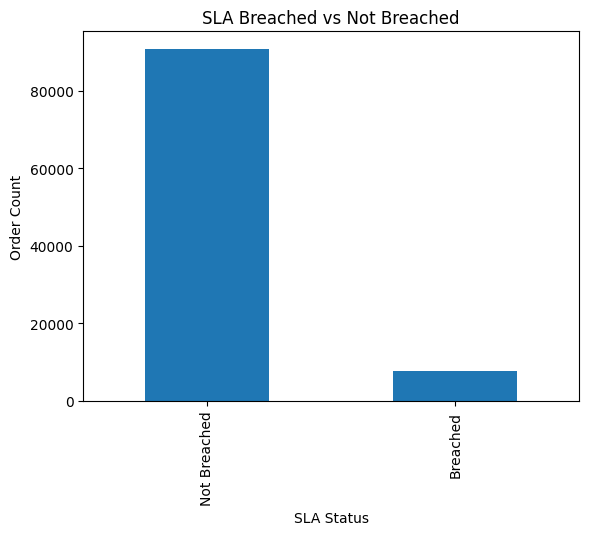

In [101]:
sla_labels = {
    0: 'Not Breached',
    1: 'Breached'
}

df['sla_breached'].map(sla_labels).value_counts().plot(kind='bar')

plt.title('SLA Breached vs Not Breached')
plt.xlabel('SLA Status')
plt.ylabel('Order Count')

plt.show()

## SLA Breach Rate by Customer State

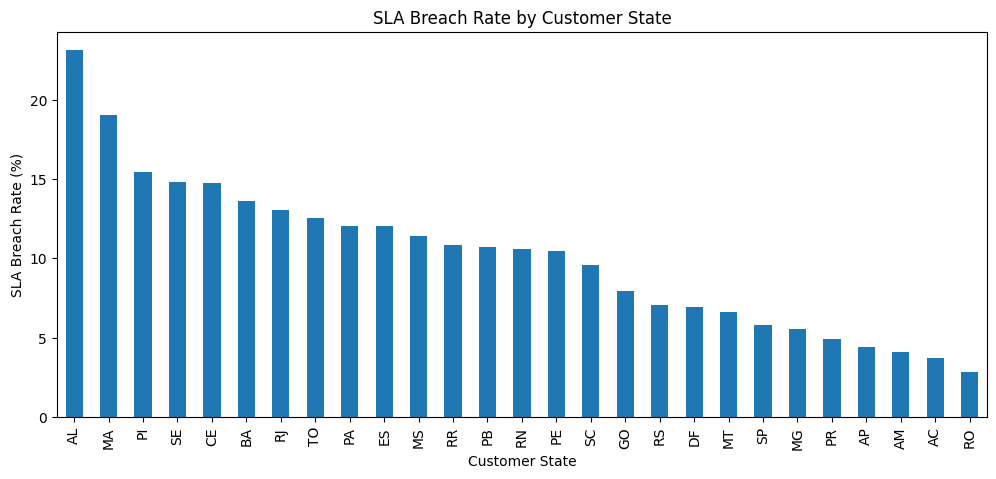

In [102]:
(
    df.groupby('customer_state')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).plot(kind='bar', figsize=(12,5))

plt.title('SLA Breach Rate by Customer State')
plt.xlabel('Customer State')
plt.ylabel('SLA Breach Rate (%)')

plt.show()

## SLA Breach Rate by Seller State

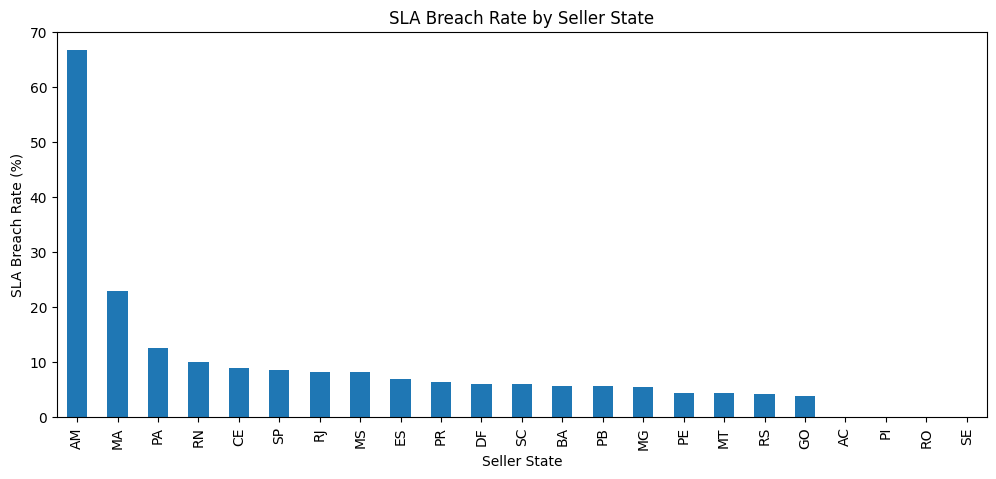

In [103]:
(
    df.groupby('seller_state')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).plot(kind='bar', figsize=(12,5))

plt.title('SLA Breach Rate by Seller State')
plt.xlabel('Seller State')
plt.ylabel('SLA Breach Rate (%)')

plt.show()

## SLA Breach Rate by Purchase Day

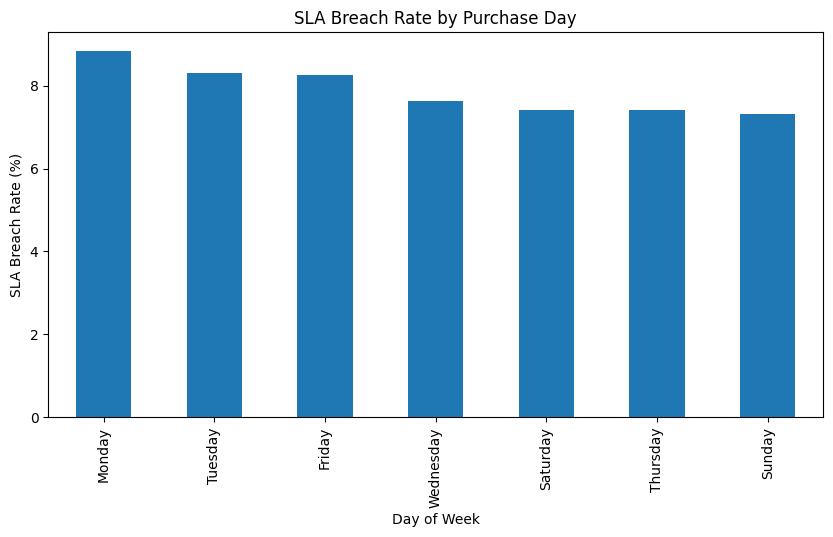

In [104]:
(
    df.groupby('purchase_day')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).plot(kind='bar', figsize=(10,5))

plt.title('SLA Breach Rate by Purchase Day')
plt.xlabel('Day of Week')
plt.ylabel('SLA Breach Rate (%)')

plt.show()

## Top 10 Product Categories by SLA Breach Rate

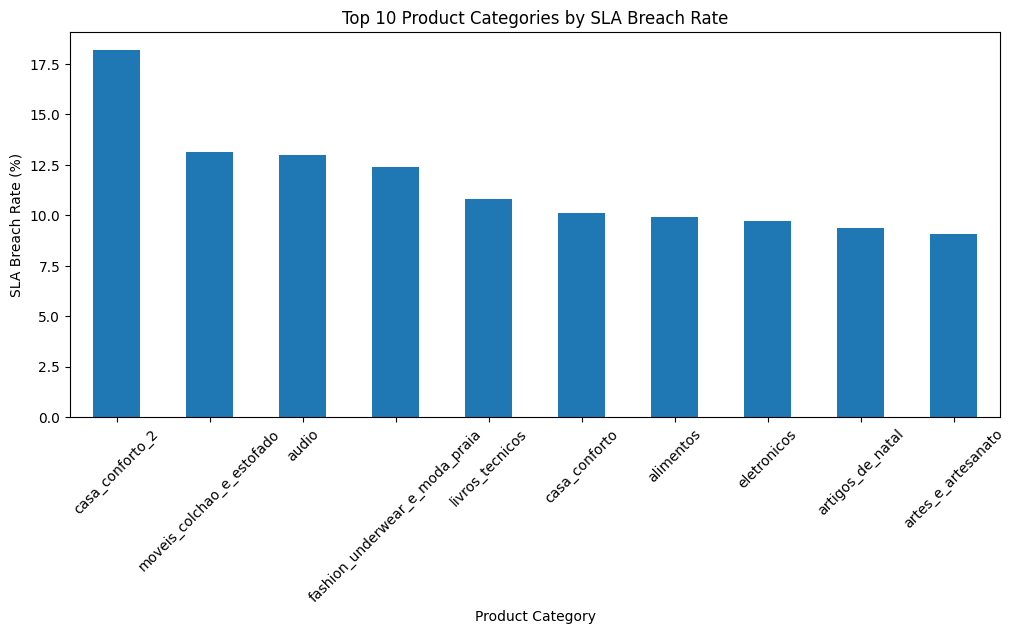

In [105]:
(
    df.groupby('product_category_name')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).plot(kind='bar', figsize=(12,5))

plt.title('Top 10 Product Categories by SLA Breach Rate')
plt.xlabel('Product Category')
plt.ylabel('SLA Breach Rate (%)')

plt.xticks(rotation=45)

plt.show()